In [1]:
%cd ..

/home/amina/amina/ws-bt-prelim/spring_03


/home/amina/miniforge3/envs/biomedclip/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
%ls 

articles/  articles.zip  Irina/  papers/  prototype/  resume/  TextBraTs/


In [3]:
import os
import json
import numpy as np
import nibabel as nib
from PIL import Image
import pandas as pd

In [4]:
DATASET_DIR   = "prototype/dataset"     
OUTPUT_DIR    = "resume/MedCLIP-SAMv2/MedCLIP-SAMv2/biomedclip_finetuning/"
PROMPTS_JSON  = "prototype/outputs/output.json"

In [5]:
os.makedirs(f"{OUTPUT_DIR}/images", exist_ok=True)

In [6]:
with open(PROMPTS_JSON, "r") as f:
    prompts = {r["id"]: r["prompt"] for r in json.load(f)}

In [7]:
%ls

articles/  articles.zip  Irina/  papers/  prototype/  resume/  TextBraTs/


In [ ]:
# extract best 2D slice from 3D volume
def extract_best_slice(nii_path):
    # extract axial slice with the most non-zero content (tumor slice)
    data = nib.load(nii_path).get_fdata(dtype=np.float32)

    # find slice with most non-zero voxels (most informative)
    nonzero_counts = [(data[:, :, i] > 0).sum() for i in range(data.shape[2])]
    best_idx = int(np.argmax(nonzero_counts))
    slice_2d = data[:, :, best_idx]

    # normalize to [0, 255]
    p1, p99 = np.percentile(slice_2d[slice_2d > 0], [1, 99])
    slice_2d = np.clip(slice_2d, p1, p99)
    slice_2d = ((slice_2d - p1) / (p99 - p1 + 1e-8) * 255).astype(np.uint8)

    return slice_2d

In [ ]:
# build image-text pairs
records = []
subfolders = sorted(
    (f for f in os.scandir(DATASET_DIR)
     if f.is_dir() and f.name.startswith("BraTS20")),
    key=lambda x: int(x.name.split('_')[-1])
)

In [ ]:
for folder in subfolders:
    case_id = folder.name

    # find .nii file
    nii_files = [f for f in os.listdir(folder.path) if f.endswith((".nii", ".nii.gz"))]
    if not nii_files:
        continue

    nii_path = os.path.join(folder.path, nii_files[0])

    # get prompt for this case
    if case_id not in prompts:
        print(f"[SKIP] No prompt for {case_id}")
        continue

    # extract best 2D slice and save as PNG
    slice_2d = extract_best_slice(nii_path)
    img_rgb = Image.fromarray(slice_2d).convert("RGB") # CLIP needs RGB
    img_rgb = img_rgb.resize((224, 224)) # standard CLIP size

    img_filename = f"{case_id}.png"
    img_rgb.save(os.path.join(OUTPUT_DIR, "images", img_filename))

    records.append({
        "image_path": f"images/{img_filename}",
        "caption": prompts[case_id],
        "id": case_id,
    })

    print(f"Saved {img_filename}")

Saved BraTS20_Training_001.png
Saved BraTS20_Training_002.png
Saved BraTS20_Training_003.png
Saved BraTS20_Training_004.png
Saved BraTS20_Training_005.png


In [ ]:
df = pd.DataFrame(records)

In [13]:
# split into train / val
split = int(len(df) * 0.85)
df.iloc[:split].to_csv(f"{OUTPUT_DIR}/train.csv", index=False)
df.iloc[split:].to_csv(f"{OUTPUT_DIR}/val.csv",   index=False)

In [14]:
print(f"Train: {split} pairs  |  Val: {len(df) - split} pairs")
print(f"Saved to: {OUTPUT_DIR}")

Train: 4 pairs  |  Val: 1 pairs
Saved to: resume/MedCLIP-SAMv2/MedCLIP-SAMv2/biomedclip_finetuning/


In [15]:
%cd resume/MedCLIP-SAMv2/MedCLIP-SAMv2/

/home/amina/amina/ws-bt-prelim/spring_03/resume/MedCLIP-SAMv2/MedCLIP-SAMv2


/home/amina/miniforge3/envs/biomedclip/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [16]:
%ls

assets/                        loss/                  sam_outputs/
biomedclip_finetuning/         medclipsamv2_env.yml   segment-anything/
biomedclip_vit_bert_hf_local/  postprocessing/        tokens/
coarse_outputs/                README.md              weak_segmentation/
evaluation/                    saliency_map_outputs/  zeroshot_scripts/
LICENSE                        saliency_maps/         zeroshot.sh


In [17]:
%cd biomedclip_finetuning/open_clip/src

/home/amina/amina/ws-bt-prelim/spring_03/resume/MedCLIP-SAMv2/MedCLIP-SAMv2/biomedclip_finetuning/open_clip/src


In [18]:
%ls

logs/  open_clip/  open_clip_train/


In [19]:
%%bash 
python3 -m open_clip_train.main \
    --batch-size 16 \
    --workers 4 \
    --report-to tensorboard \
    --save-frequency 1 \
    --logs="logs" \
    --dataset-type csv \
    --csv-separator="," \
    --train-data /home/amina/amina/ws-bt-prelim/spring_03/prototype/MedCLIP-SAMv2/biomedclip_finetuning/train.csv \
    --csv-img-key image_path \
    --csv-caption-key caption \
    --lr=1e-3 \
    --wd=0.1 \
    --warmup 1000 \
    --epochs=10 \
    --model hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224 \
    --dhnnce-loss \
    --temperature-dhnnce 0.6 \
    --alpha-dhnnce 0.0 \
    --beta1-dhnnce 0.15 \
    --beta2-dhnnce 0.15 2>&1 | tail -50

  "use_cache": true,
  "vocab_size": 30522
}

loading configuration file config.json from cache at /home/amina/.cache/huggingface/hub/models--microsoft--BiomedNLP-BiomedBERT-base-uncased-abstract/snapshots/d673b8835373c6fa116d6d8006b33d48734e305d/config.json
Model config BertConfig {
  "_name_or_path": "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.35.2",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

2026-04-05,07:20:38 | INFO | Start epoch 0
/home/amina/miniforge3/envs/biomedcli

In [20]:
%ls 

logs/  open_clip/  open_clip_train/


In [21]:
# convert .pt checkpoint → .bin (required by the saliency map pipeline)
import shutil

In [22]:
# move your best checkpoint
shutil.copy(
    "/home/amina/amina/ws-bt-prelim/spring_03/resume/MedCLIP-SAMv2/MedCLIP-SAMv2/biomedclip_finetuning/open_clip/src/logs/2026_04_05-07_20_31-model_hf-hub:microsoft-BiomedCLIP-PubMedBERT_256-vit_base_patch16_224-lr_0.001-b_16-j_4-p_amp/checkpoints/epoch_10.pt",
    "/home/amina/amina/ws-bt-prelim/spring_03/resume/MedCLIP-SAMv2/MedCLIP-SAMv2/saliency_maps/model/pytorch_model.pt"
)

'/home/amina/amina/ws-bt-prelim/spring_03/resume/MedCLIP-SAMv2/MedCLIP-SAMv2/saliency_maps/model/pytorch_model.pt'

In [23]:
%ls

logs/  open_clip/  open_clip_train/


In [24]:
%cd /home/amina/amina/ws-bt-prelim/spring_03/resume/MedCLIP-SAMv2/MedCLIP-SAMv2/

/home/amina/amina/ws-bt-prelim/spring_03/resume/MedCLIP-SAMv2/MedCLIP-SAMv2


/home/amina/miniforge3/envs/biomedclip/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [25]:
%ls

assets/                        loss/                  sam_outputs/
biomedclip_finetuning/         medclipsamv2_env.yml   segment-anything/
biomedclip_vit_bert_hf_local/  postprocessing/        tokens/
coarse_outputs/                README.md              weak_segmentation/
evaluation/                    saliency_map_outputs/  zeroshot_scripts/
LICENSE                        saliency_maps/         zeroshot.sh


In [26]:
import torch
import glob
import os

In [ ]:
pt_files = glob.glob("saliency_maps/model/*.pt")
checkpoint = torch.load(pt_files[0], map_location="cpu")

In [28]:
print("Keys in checkpoint:", list(checkpoint.keys()))

Keys in checkpoint: ['epoch', 'name', 'state_dict', 'optimizer', 'scaler']


In [29]:
# extract just the model weights
state_dict = checkpoint["state_dict"]

In [30]:
cleaned = {}
for k, v in state_dict.items():
    new_key = k.replace("model.", "") if k.startswith("model.") else k
    cleaned[new_key] = v

In [31]:
print(f"total keys after cleaning: {len(cleaned)}")
print("sample keys:", list(cleaned.keys())[:5])

total keys after cleaning: 351
sample keys: ['logit_scale', 'visual.trunk.cls_token', 'visual.trunk.pos_embed', 'visual.trunk.patch_embed.proj.weight', 'visual.trunk.patch_embed.proj.bias']


In [32]:
# save as a clean weights-only .pt 
clean_path = "saliency_maps/model/pytorch_model_weights_only.pt"
torch.save(cleaned, clean_path)
print(f"saved clean weights to: {clean_path}")

saved clean weights to: saliency_maps/model/pytorch_model_weights_only.pt


In [ ]:
import open_clip

model, _, _ = open_clip.create_model_and_transforms(
    "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
)

/home/amina/miniforge3/envs/biomedclip/lib/python3.10/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/amina/miniforge3/envs/biomedclip/lib/python3.10/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/amina/miniforge3/envs/biomedclip/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/amina/miniforge3/envs/biomedclip/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` 

In [34]:
missing, unexpected = model.load_state_dict(cleaned, strict=False)
print(f"missing keys  : {len(missing)}")
print(f"unexpected keys: {len(unexpected)}")

missing keys  : 0
unexpected keys: 0


In [35]:
# overwrite the .pt so convert.py finds it
import shutil

In [36]:
# backup original
shutil.copy(pt_files[0], pt_files[0] + ".backup")

'saliency_maps/model/pytorch_model.pt.backup'

In [37]:
# replace with clean weights
torch.save(cleaned, pt_files[0])

In [38]:
%cd /home/amina/amina/ws-bt-prelim/spring_03/resume/MedCLIP-SAMv2/MedCLIP-SAMv2

/home/amina/amina/ws-bt-prelim/spring_03/resume/MedCLIP-SAMv2/MedCLIP-SAMv2


/home/amina/miniforge3/envs/biomedclip/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [39]:
%pwd

'/home/amina/amina/ws-bt-prelim/spring_03/resume/MedCLIP-SAMv2/MedCLIP-SAMv2'

In [40]:
# run convert.py
!python saliency_maps/model/convert.py

/home/amina/miniforge3/envs/biomedclip/lib/python3.10/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/amina/miniforge3/envs/biomedclip/lib/python3.10/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/amina/miniforge3/envs/biomedclip/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/amina/miniforge3/envs/biomedclip/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` 

In [41]:
import torch
import open_clip

In [42]:
%ls

assets/                        loss/                  sam_outputs/
biomedclip_finetuning/         medclipsamv2_env.yml   segment-anything/
biomedclip_vit_bert_hf_local/  postprocessing/        tokens/
coarse_outputs/                README.md              weak_segmentation/
evaluation/                    saliency_map_outputs/  zeroshot_scripts/
LICENSE                        saliency_maps/         zeroshot.sh


In [43]:
# load fine-tuned weights
checkpoint = torch.load("saliency_maps/model/pytorch_model.bin")

In [44]:
tokenizer = open_clip.get_tokenizer(
    "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
)

integrate medclip seg 

In [45]:
import os, sys, json, torch, numpy as np
from PIL import Image
import open_clip

In [ ]:
BASE = "/home/amina/amina/ws-bt-prelim/spring_03/resume/MedCLIP-SAMv2/MedCLIP-SAMv2"
MEDCLIPSEG = "/home/amina/amina/ws-bt-prelim/spring_03/resume/MedCLIPSeg"
IMAGES_DIR = f"{BASE}/biomedclip_finetuning/images"
PROMPTS_JSON = "/home/amina/amina/ws-bt-prelim/spring_03/prototype/outputs/output.json"
WEIGHTS_PATH = f"{BASE}/saliency_maps/model/pytorch_model.pt"
SAM_CKPT = f"{BASE}/segment-anything/sam_checkpoints/sam_vit_h_4b8939.pth"
OUTPUT_DIR = "/home/amina/amina/ws-bt-prelim/spring_03/prototype/outputs/masks"
TOKENS_DIR = "/home/amina/amina/ws-bt-prelim/spring_03/prototype/outputs/tokens"

In [47]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(TOKENS_DIR,  exist_ok=True)

In [48]:
# add MedCLIPSeg to path so we can import its modules
sys.path.insert(0, MEDCLIPSEG)

In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cpu


load fine-tuned BiomedCLIP and extract patch tokens (B, N, D) and text tokens (B, L, D)

instead of calling encode_image() which gives only the CLS token (B, D) we will hook into the ViT to get all patch tokens (B, N, D) and into the text transformer for all token positions (B, L, D)

In [50]:
model, _, preprocess = open_clip.create_model_and_transforms(
    "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
)
tokenizer = open_clip.get_tokenizer(
    "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
)

In [51]:
state_dict = torch.load(WEIGHTS_PATH, map_location="cpu")

In [52]:
model.load_state_dict(state_dict)

<All keys matched successfully>

In [53]:
model.eval().to(device)

CustomTextCLIP(
  (visual): TimmModel(
    (trunk): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=768, out_features=768, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
          

In [54]:
# load prompts 
with open(PROMPTS_JSON) as f:
    prompts = {r["id"]: r["prompt"] for r in json.load(f)}

In [55]:
# hook functions to extract intermediate tokens 
_image_patch_tokens = {}
_text_all_tokens    = {}

In [56]:
def hook_image_patches(module, input, output):
    # captures all patch tokens (B, N, D) from the last ViT block, the output shape from ViT block: (B, N+1, D) — N patches + 1 CLS
    _image_patch_tokens["tokens"] = output.detach()

In [57]:
def hook_text_tokens(module, input, output):
    # captures all text token hidden states (B, L, D)
    _text_all_tokens["tokens"] = output[0].detach()

In [58]:
# register hooks on the last transformer block of each encoder
image_hook = model.visual.trunk.blocks[-1].register_forward_hook(hook_image_patches)
text_hook  = model.text.transformer.encoder.layer[-1].register_forward_hook(hook_text_tokens)

In [ ]:
all_records = []
img_files = sorted([f for f in os.listdir(IMAGES_DIR) if f.endswith(".png")])

for img_file in img_files:
    case_id = img_file.replace(".png", "")
    if case_id not in prompts:
        print(f"[SKIP] {case_id}")
        continue

    img_tensor  = preprocess(
        Image.open(os.path.join(IMAGES_DIR, img_file)).convert("RGB")
    ).unsqueeze(0).to(device)

    text_tokens = tokenizer([prompts[case_id]]).to(device)

    with torch.no_grad():
        _ = model.encode_image(img_tensor)
        _ = model.encode_text(text_tokens)

    img_patch_tokens = _image_patch_tokens["tokens"] # (1, 197, 768)
    txt_all_tokens = _text_all_tokens["tokens"] # (1, 77,  768)

    torch.save(img_patch_tokens.cpu(),
               os.path.join(TOKENS_DIR, f"{case_id}_img_tokens.pt"))
    torch.save(txt_all_tokens.cpu(),
               os.path.join(TOKENS_DIR, f"{case_id}_txt_tokens.pt"))
    torch.save(text_tokens.cpu(),
               os.path.join(TOKENS_DIR, f"{case_id}_txt_ids.pt"))

    all_records.append({
        "id": case_id,
        "img_shape": list(img_patch_tokens.shape),
        "txt_shape": list(txt_all_tokens.shape),
    })
    print(f"{case_id}  img={img_patch_tokens.shape}  txt={txt_all_tokens.shape}")

# remove hooks when done
image_hook.remove()
text_hook.remove()
print(f"tokens saved for {len(all_records)} cases")

BraTS20_Training_001  img=torch.Size([1, 197, 768])  txt=torch.Size([1, 256, 768])
BraTS20_Training_002  img=torch.Size([1, 197, 768])  txt=torch.Size([1, 256, 768])
BraTS20_Training_003  img=torch.Size([1, 197, 768])  txt=torch.Size([1, 256, 768])
BraTS20_Training_004  img=torch.Size([1, 197, 768])  txt=torch.Size([1, 256, 768])
BraTS20_Training_005  img=torch.Size([1, 197, 768])  txt=torch.Size([1, 256, 768])
tokens saved for 5 cases


define the PVL adapter (probabilistic cross-modal attention): bidirectional cross-modal attention with variational (probabilistic) Key-Value pairs

PVL performs bidirectional cross-modal attention between image patch tokens and text tokens with probabilistic (variational) Key-Value formulations

d_model: token dimension (768 for BiomedCLIP ViT-B/16), n_heads : number of attention heads, beta: confidence weight for uncertainty-aware attention (paper: 2.35)

In [60]:
import torch.nn as nn
import torch.nn.functional as F

In [61]:
class PVLAdapter(nn.Module):
    def __init__(self, d_model=768, n_heads=8, beta=2.35):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.beta    = beta
        self.d_head  = d_model // n_heads

        # image → text (Q from text, K/V from image)
        self.q_i2t        = nn.Linear(d_model, d_model)
        self.k_i2t_mu     = nn.Linear(d_model, d_model)
        self.k_i2t_logvar = nn.Linear(d_model, d_model)
        self.v_i2t_mu     = nn.Linear(d_model, d_model)
        self.v_i2t_logvar = nn.Linear(d_model, d_model)
        self.out_i2t      = nn.Linear(d_model, d_model)

        # text → image (Q from image, K/V from text)
        self.q_t2i        = nn.Linear(d_model, d_model)
        self.k_t2i_mu     = nn.Linear(d_model, d_model)
        self.k_t2i_logvar = nn.Linear(d_model, d_model)
        self.v_t2i_mu     = nn.Linear(d_model, d_model)
        self.v_t2i_logvar = nn.Linear(d_model, d_model)
        self.out_t2i      = nn.Linear(d_model, d_model)

        self.gate_i2t = nn.Parameter(torch.zeros(1))
        self.gate_t2i = nn.Parameter(torch.zeros(1))
        self.norm_img = nn.LayerNorm(d_model)
        self.norm_txt = nn.LayerNorm(d_model)

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return mu

    def cross_attention(self, Q_proj, K_mu, K_logvar, V_mu, V_logvar):
        B, Nq, _ = Q_proj.shape
        K = self.reparameterize(K_mu, K_logvar)
        V = self.reparameterize(V_mu, V_logvar)
        conf = self.beta * torch.exp(-K_logvar)

        def to_heads(x):
            return x.view(B, -1, self.n_heads, self.d_head).transpose(1, 2)

        Q = to_heads(Q_proj)
        K = to_heads(K)
        V = to_heads(V)
        C = to_heads(conf).mean(-1, keepdim=True)

        attn = (Q @ K.transpose(-2, -1)) * (self.d_head ** -0.5)
        attn = attn * C.transpose(-2, -1)
        attn = F.softmax(attn, dim=-1)
        out  = (attn @ V).transpose(1, 2).reshape(B, Nq, self.d_model)
        uncertainty = K_logvar.mean(dim=-1)   # (B, Nk)
        return out, uncertainty

    def forward(self, img_tokens, txt_tokens):
        # text → image
        Q_t2i = self.q_t2i(img_tokens)
        delta_img, txt_unc = self.cross_attention(
            Q_t2i,
            self.k_t2i_mu(txt_tokens), self.k_t2i_logvar(txt_tokens),
            self.v_t2i_mu(txt_tokens), self.v_t2i_logvar(txt_tokens),
        )
        fused_img = self.norm_img(
            img_tokens + torch.tanh(self.gate_t2i) * self.out_t2i(delta_img)
        )

        # image → text
        Q_i2t = self.q_i2t(txt_tokens)
        delta_txt, img_unc = self.cross_attention(
            Q_i2t,
            self.k_i2t_mu(img_tokens), self.k_i2t_logvar(img_tokens),
            self.v_i2t_mu(img_tokens), self.v_i2t_logvar(img_tokens),
        )
        fused_txt = self.norm_txt(
            txt_tokens + torch.tanh(self.gate_i2t) * self.out_i2t(delta_txt)
        )

        return fused_img, fused_txt, img_unc, txt_unc

segmentation head

In [ ]:
class SegmentationHead(nn.Module):
    # takes fused image tokens and produces 2D probability map at the patch grid resolution then upsamples to full image resolution
    # input: (B, N, D) where N = H_p * W_p (196 patches for 224px / 16px)
    # output: (B, 1, H, W) probability map
    def __init__(self, d_model=768, patch_size=16, img_size=224):
        super().__init__()
        self.grid_size = img_size // patch_size   # 14

        self.proj = nn.Sequential(
            nn.Linear(d_model, 256),
            nn.GELU(),
            nn.Linear(256, 1),
        )
        self.upsample = nn.Upsample(
            size=(img_size, img_size), mode="bilinear", align_corners=False
        )

    def forward(self, fused_img_tokens):
        # drop CLS token at position 0, keep patch tokens
        patch_tokens = fused_img_tokens[:, 1:, :] # (B, 196, 768)
        B, N, D = patch_tokens.shape
        scores = self.proj(patch_tokens).squeeze(-1) # (B, 196)
        scores = scores.view(B, 1, self.grid_size, self.grid_size)  # (B, 1, 14, 14)
        seg_map = torch.sigmoid(self.upsample(scores)) # (B, 1, 224, 224)
        return seg_map

run PVL + segmentation head

In [63]:
# init PVL and seg head 
pvl = PVLAdapter(d_model=768, n_heads=8, beta=2.35).to(device)
seg_head = SegmentationHead(d_model=768, patch_size=16, img_size=224).to(device)

In [64]:
pvl.eval()

PVLAdapter(
  (q_i2t): Linear(in_features=768, out_features=768, bias=True)
  (k_i2t_mu): Linear(in_features=768, out_features=768, bias=True)
  (k_i2t_logvar): Linear(in_features=768, out_features=768, bias=True)
  (v_i2t_mu): Linear(in_features=768, out_features=768, bias=True)
  (v_i2t_logvar): Linear(in_features=768, out_features=768, bias=True)
  (out_i2t): Linear(in_features=768, out_features=768, bias=True)
  (q_t2i): Linear(in_features=768, out_features=768, bias=True)
  (k_t2i_mu): Linear(in_features=768, out_features=768, bias=True)
  (k_t2i_logvar): Linear(in_features=768, out_features=768, bias=True)
  (v_t2i_mu): Linear(in_features=768, out_features=768, bias=True)
  (v_t2i_logvar): Linear(in_features=768, out_features=768, bias=True)
  (out_t2i): Linear(in_features=768, out_features=768, bias=True)
  (norm_img): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (norm_txt): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)

In [65]:
seg_head.eval()

SegmentationHead(
  (proj): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=256, out_features=1, bias=True)
  )
  (upsample): Upsample(size=(224, 224), mode='bilinear')
)

In [ ]:
import cv2
import sys
sys.path.append("/home/amina/amina/ws-bt-prelim/spring_03/resume/MedCLIP-SAMv2/MedCLIP-SAMv2/segment-anything")
from segment_anything import sam_model_registry, SamPredictor
_CONTOUR_INDEX = 1 if cv2.__version__.split('.')[0] == '3' else 0

In [67]:
sam_checkpoint = "/home/amina/amina/ws-bt-prelim/spring_03/resume/MedCLIP-SAMv2/MedCLIP-SAMv2/segment-anything/segment_anything/sam_vit_h_4b8939.pth"
model_type = "vit_h"

In [68]:
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)

In [69]:
sam.to(device=device)

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 1280, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-31): 32 x Block(
        (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=1280, out_features=3840, bias=True)
          (proj): Linear(in_features=1280, out_features=1280, bias=True)
        )
        (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=1280, out_features=5120, bias=True)
          (lin2): Linear(in_features=5120, out_features=1280, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(1280, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d

In [70]:
predictor = SamPredictor(sam)

In [ ]:
all_fused = []

for img_file in sorted(os.listdir(IMAGES_DIR)):
    if not img_file.endswith(".png"):
        continue
    case_id = img_file.replace(".png", "")

    img_tok_path = os.path.join(TOKENS_DIR, f"{case_id}_img_tokens.pt")
    txt_tok_path = os.path.join(TOKENS_DIR, f"{case_id}_txt_tokens.pt")
    if not os.path.exists(img_tok_path):
        print(f"[SKIP] no tokens for {case_id}")
        continue

    img_tokens = torch.load(img_tok_path).to(device) # (1, 197, 768)
    txt_tokens = torch.load(txt_tok_path).to(device) # (1, 77,  768)

    with torch.no_grad():

        # PVL fusion
        fused_img, fused_txt, img_unc, txt_unc = pvl(img_tokens, txt_tokens)

        # patch-level similarity from RAW BiomedCLIP tokens 
        # use the frozen BiomedCLIP tokens (not PVL output) for the saliency map because PVL is untrained and its output is not meaningful yet
        raw_patches = img_tokens[:, 1:, :] # (1, 196, 768) drop CLS
        raw_text_query = txt_tokens.mean(dim=1, keepdim=True) # (1, 1, 768) mean pooling

        # L2 normalize
        raw_patches_n = F.normalize(raw_patches, dim=-1) # (1, 196, 768)
        raw_text_n = F.normalize(raw_text_query, dim=-1) # (1, 1,   768)

        # cosine similarity per patch
        sim_map  = (raw_patches_n @ raw_text_n.transpose(-1, -2))  # (1, 196, 1)
        sim_map  = sim_map.squeeze().cpu().numpy() # (196,)
        sim_grid = sim_map.reshape(14, 14) # (14, 14)

        # normalize to [0, 1]
        s_min, s_max = sim_grid.min(), sim_grid.max()
        sim_norm = (sim_grid - s_min) / (s_max - s_min + 1e-8)

        # build coarse mask from top 25% similar patches
        threshold = np.percentile(sim_norm, 75)
        coarse_14 = (sim_norm > threshold).astype(np.uint8)
        coarse_mask = np.array(
            Image.fromarray(coarse_14 * 255).resize((224, 224), Image.NEAREST)
        )
        coarse_mask  = (coarse_mask > 127).astype(np.uint8)

    # find peak point (inside brain mask only) and exclude pure black background (brain mask)
    img_gray = np.array(
        Image.open(os.path.join(IMAGES_DIR, img_file)).convert("L").resize((224, 224))
    )
    brain_mask = (img_gray > 10).astype(np.uint8) # non-background pixels only

    # multiply similarity map (upsampled) by brain mask to avoid corner points
    sim_full = np.array(
        Image.fromarray((sim_norm * 255).astype(np.uint8)).resize((224, 224), Image.BILINEAR)
    ).astype(np.float32) / 255.0
    sim_full_masked = sim_full * brain_mask # zero out background

    # find peak point within brain
    flat_idx = sim_full_masked.flatten().argmax()
    peak_row = int(flat_idx // 224)
    peak_col = int(flat_idx  % 224)

    # SAM with both box + point prompts
    img_np = np.array(
        Image.open(os.path.join(IMAGES_DIR, img_file)).convert("RGB").resize((224, 224))
    )
    predictor.set_image(img_np)

    # bounding box from coarse mask (restricted to brain area)
    coarse_in_brain = coarse_mask * brain_mask
    ys, xs = np.where(coarse_in_brain > 0)

    if len(xs) > 0:
        # add small padding to box
        pad = 5
        x1 = max(0,   xs.min() - pad)
        y1 = max(0,   ys.min() - pad)
        x2 = min(223, xs.max() + pad)
        y2 = min(223, ys.max() + pad)
        box = np.array([x1, y1, x2, y2])
    else:
        box = None

    point_coords = np.array([[peak_col, peak_row]])
    point_labels = np.array([1])   # 1 = foreground

    sam_masks, scores_sam, _ = predictor.predict(
        point_coords = point_coords,
        point_labels = point_labels,
        box = box,
        multimask_output = True, # get 3 candidates
    )

    # pick the smallest mask that still contains the peak point (avoids SAM picking the whole brain)
    valid_masks = []
    for m, s in zip(sam_masks, scores_sam):
        if m[peak_row, peak_col]: # mask must cover the peak point
            valid_masks.append((m, s, m.sum()))

    if valid_masks:
        # among valid masks, prefer the smallest (most focused on tumor)
        valid_masks.sort(key=lambda x: x[2]) # sort by mask area ascending
        final_mask_bool, best_score, _ = valid_masks[0]
    else:
        # fallback: just use highest confidence mask
        best_idx = scores_sam.argmax()
        final_mask_bool = sam_masks[best_idx]
        best_score = scores_sam[best_idx]

    final_mask = final_mask_bool.astype(np.uint8) * 255

    mask_path = os.path.join(OUTPUT_DIR, f"{case_id}_mask.png")
    sal_path = os.path.join(OUTPUT_DIR, f"{case_id}_saliency.png")
    Image.fromarray(final_mask).save(mask_path)
    Image.fromarray((sim_norm * 255).astype(np.uint8)).resize(
        (224, 224), Image.BILINEAR
    ).save(sal_path)

    torch.save(fused_img.cpu(), os.path.join(TOKENS_DIR, f"{case_id}_fused_img.pt"))
    torch.save(fused_txt.cpu(), os.path.join(TOKENS_DIR, f"{case_id}_fused_txt.pt"))
    torch.save(img_unc.cpu(),   os.path.join(TOKENS_DIR, f"{case_id}_img_uncertainty.pt"))
    torch.save(txt_unc.cpu(),   os.path.join(TOKENS_DIR, f"{case_id}_txt_uncertainty.pt"))

    all_fused.append({
        "id": case_id,
        "mask_path": mask_path,
        "sal_path": sal_path,
        "sam_score": float(best_score),
        "peak_point": [int(peak_col), int(peak_row)],
        "mask_area": int(final_mask_bool.sum()),
    })
    print(f"{case_id}  peak=({peak_col},{peak_row})  area={final_mask_bool.sum()}  score={best_score:.3f}")

print(f"{len(all_fused)} masks saved")

BraTS20_Training_001  peak=(151,103)  area=4816  score=0.979
BraTS20_Training_002  peak=(119,72)  area=1004  score=0.949
BraTS20_Training_003  peak=(136,119)  area=2996  score=0.653
BraTS20_Training_004  peak=(136,135)  area=1498  score=0.968
BraTS20_Training_005  peak=(151,87)  area=5518  score=0.774
5 masks saved


In [72]:
# save summary
with open(os.path.join(TOKENS_DIR, "fused_tokens_summary.json"), "w") as f:
    json.dump(all_fused, f, indent=2)

obtained results

In [73]:
import matplotlib.pyplot as plt

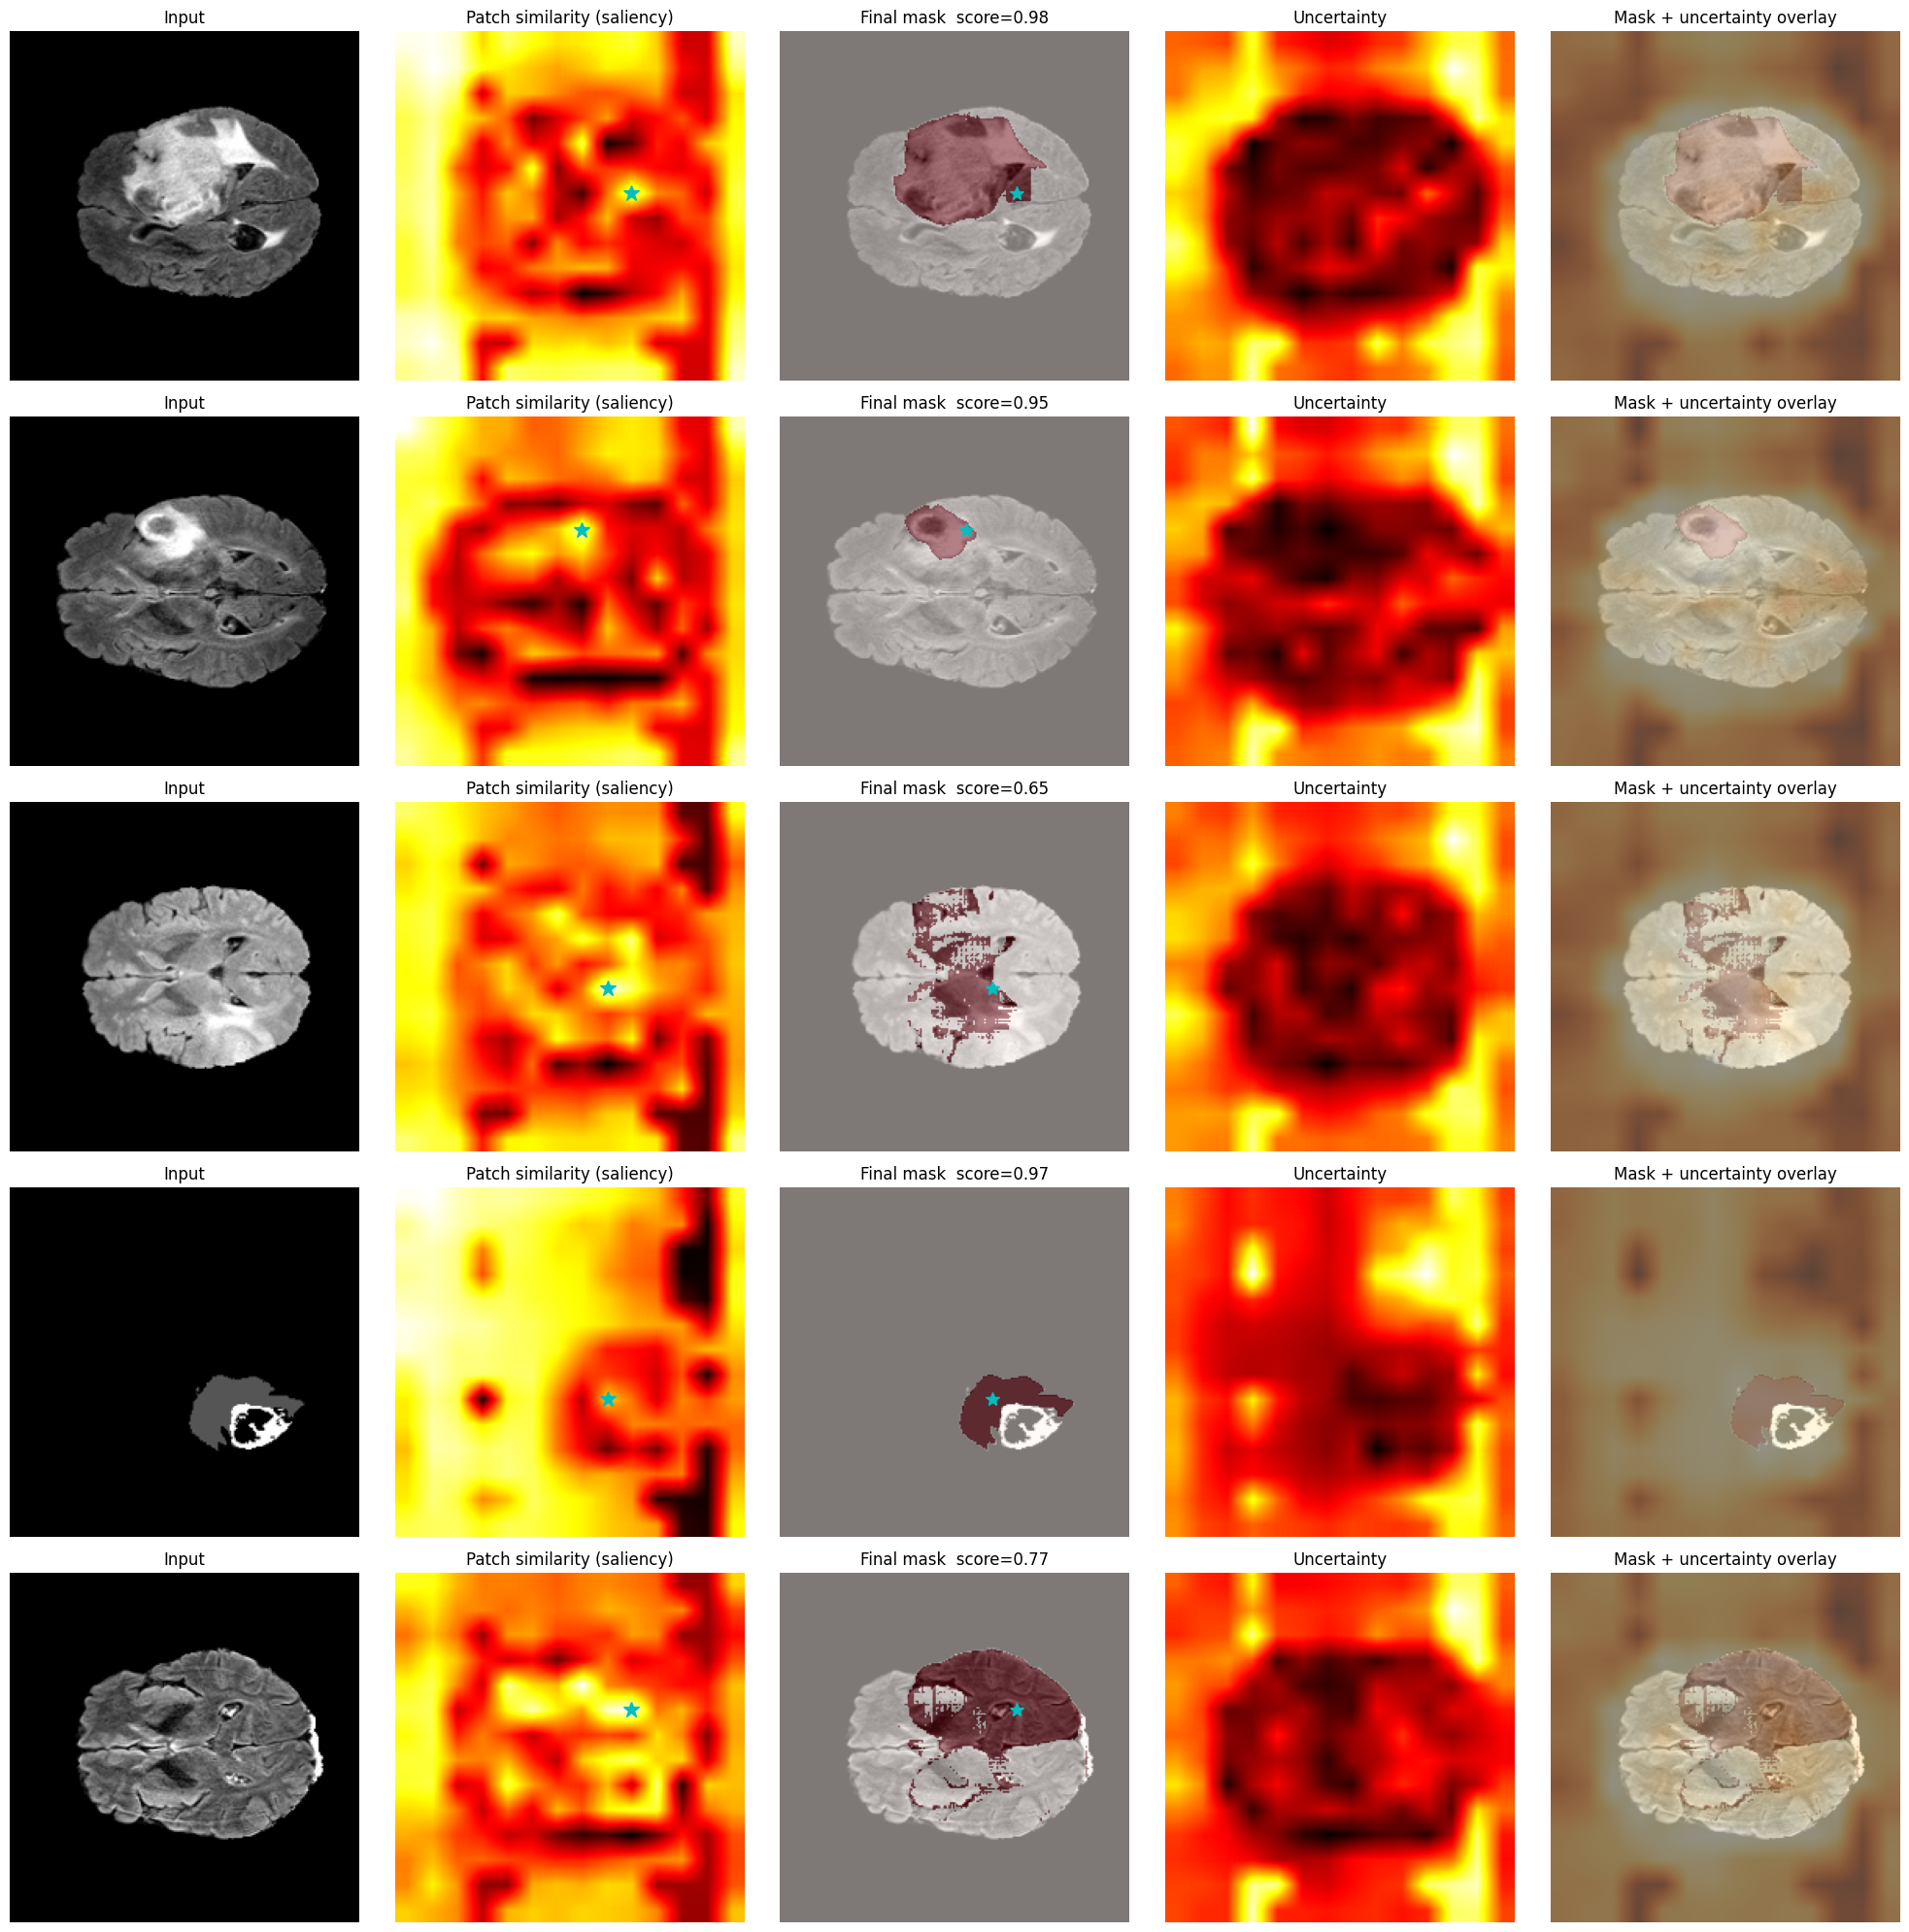

Saved.


In [ ]:
n = len(all_fused)
fig, axes = plt.subplots(n, 5, figsize=(20, 4 * n))
if n == 1: axes = [axes]

for i, rec in enumerate(all_fused):
    case_id = rec["id"]

    img_np  = np.array(Image.open(os.path.join(IMAGES_DIR, f"{case_id}.png")).resize((224,224)))
    mask_np = np.array(Image.open(rec["mask_path"]))
    sal_np  = np.array(Image.open(rec["sal_path"]).resize((224, 224)))

    img_unc  = torch.load(os.path.join(TOKENS_DIR, f"{case_id}_img_uncertainty.pt"))
    unc_flat = img_unc.squeeze()
    if unc_flat.shape[0] == 197:
        unc_flat = unc_flat[1:]
    unc_grid = unc_flat.reshape(14, 14).numpy()
    unc_norm = (unc_grid - unc_grid.min()) / (unc_grid.max() - unc_grid.min() + 1e-8)
    unc_up   = np.array(Image.fromarray(
        (unc_norm * 255).astype(np.uint8)).resize((224, 224), Image.BILINEAR))

    px, py = rec["peak_point"]

    axes[i][0].imshow(img_np, cmap="gray")
    axes[i][0].set_title("Input"); axes[i][0].axis("off")

    axes[i][1].imshow(sal_np, cmap="hot")
    axes[i][1].plot(px, py, "c*", markersize=12, label="SAM point")
    axes[i][1].set_title("Patch similarity (saliency)"); axes[i][1].axis("off")

    axes[i][2].imshow(img_np, cmap="gray")
    axes[i][2].imshow(mask_np, alpha=0.5, cmap="Reds")
    axes[i][2].plot(px, py, "c*", markersize=10)
    axes[i][2].set_title(f"Final mask  score={rec['sam_score']:.2f}"); axes[i][2].axis("off")

    axes[i][3].imshow(unc_up, cmap="hot")
    axes[i][3].set_title("Uncertainty"); axes[i][3].axis("off")

    axes[i][4].imshow(img_np, cmap="gray")
    axes[i][4].imshow(mask_np, alpha=0.35, cmap="Reds")
    axes[i][4].imshow(unc_up,  alpha=0.35, cmap="YlOrBr")
    axes[i][4].set_title("Mask + uncertainty overlay"); axes[i][4].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pvl_results.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")